In [18]:
from advisor_backend.interface import Interface
import matplotlib.pyplot as plt
import pandas as pd

# 总体性能拆解分析
### 1. 数据准备
我们当前支持Ascend PyTorch Profiler工具采集到的性能数据，您需要采集到的profiling_path路径，指定到*_ascend_pt。

### 2. 拆解项说明
将整体耗时拆解为计算（Computing Time）、通信（Uncovered Communication Time）和空闲（Free Time）3个部分。

1）. Computing Time：指device在执行计算的耗时，若存在多条流并行计算的情况，对于耗时重叠部分只会计算一次

计算耗时细分如下

    Cube Time：Cube算子耗时，该耗时占Computing Time的60%以上更能充分发挥NPU的算力
    Vector Time：Vector算子耗时
    Flash Attention Time(Forward)：Flash Attention算子前向耗时
    Flash Attention Time(Backward)：Flash Attention算子反向耗时
    Oter Time：AI CPU、DSA、TensorMove等其他算子耗时
    
2）. Uncovered Communication Time：未被计算掩盖的通信耗时，即总通信耗时减去通信与计算并行执行的耗时

3）. Free Time：指device既不在通信又不在计算的时间，空闲耗时 = 整体耗时 - 计算耗时 - 未被计算掩盖的通信耗时，该时间包含下发调度、SDMA时间（内存拷贝时间）。该耗时建议保持在10%以下

空闲耗时细分如下

    SDMA Time：内存拷贝任务的耗时

<font color=red>特别说明：通信（Uncovered Communication Time）和空闲（Free Time）耗时会受profiling性能膨胀的影响，以L0 + NPU采集的profiling为准。</font>

In [19]:
# 数据准备 EDIT THE PROFILING DATA PATH
profiling_path = "YOUR PATH"
# 若您有GPU上采集到的性能数据，可将NPU的性能数据与GPU之间进行对比，分析性能差距。输入GPU的性能数据路径
gpu_profiling_path = ""    #默认为空，若有则可填写
interface = Interface(profiling_path)

## 1) 性能拆解分析

In [20]:
print("Start performance analysis, please wait...")
dataset = interface.get_data('overall', 'summary', base_collection_path=gpu_profiling_path)
data = dataset.get('data', {}) or {}
bottleneck = dataset.get('bottleneck', {}) or {}
print("Performance analysis is complete, you can edit the data to show what you want.")

In [ ]:
# 等待性能分析完成后再查看数据

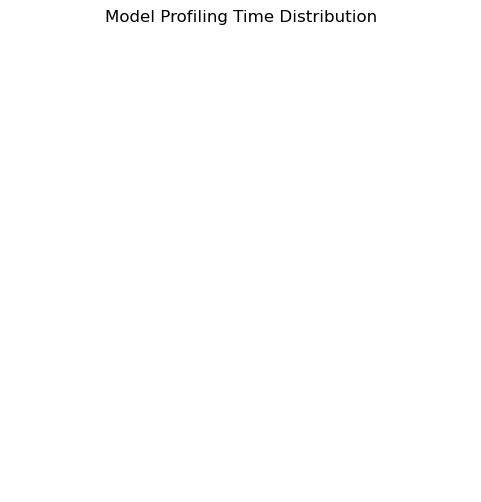

None


In [25]:
# 饼图展示计算、通信、空闲耗时的占比
overall_data = data.get("overall_data", {})
plt.figure(figsize=(6, 6))  #设置饼图大小
plt.pie(x=overall_data.values(), labels=overall_data.keys(), explode=[0.01]*len(overall_data), autopct="%1.1f%%")
plt.title("Model Profiling Time Distribution")
plt.show()
print(bottleneck.get("overall_data", ""))

In [21]:
# 展示计算细分耗时，NPU开启level1或level2，aic_metric设为AicPipeUtilization
compute_time = data.get("computing", {})
print(pd.DataFrame(compute_time))
print("\n", bottleneck.get("computing", ""))

Empty DataFrame
Columns: []
Index: []



In [22]:
# 展示通信细分耗时，通信耗时受profiling性能膨胀的影响，以L0 + NPU采集的profiling为准
communication_time = data.get("communication", {})
print(pd.DataFrame(communication_time))
print("\n", bottleneck.get("communication", ""))

Empty DataFrame
Columns: []
Index: []



In [23]:
# 展示空闲细分耗时，该耗时受profiling性能膨胀的影响，以L0 + NPU采集的profiling为准
free_time = data.get("free", {})
print(pd.DataFrame(free_time))
print("\n", bottleneck.get("free", ""))

Empty DataFrame
Columns: []
Index: []



## 2）有对标的GPU数据

In [24]:
# 有可对比的GPU数据情况下，展示比对结果
from prettytable import PrettyTable
comparison_result = data.get("comparison_result")
if not comparison_result:
    print("Invalid comparison data, you need to set the gpu_profiling_path.")
if comparison_result:
    for sheet_name, data in comparison_result.items():
        if data.get("rows", []):
            table = PrettyTable()
            table.title = sheet_name
            table.field_names = data.get("headers", [])
            for row in data.get("rows", []):
                table.add_row(row)
            print(table)
    print(bottleneck.get("comparison_result", ""))

ModuleNotFoundError: No module named 'PrettyTable'